In [ ]:
import os
os.chdir("..")

In [12]:
from data import NYUv2Dataset
import numpy as np
import torch
import matplotlib.pyplot as plt

In [11]:
print(os.getcwd())

/home/totallynotminh/Documents/TwinForge


In [14]:
data_path = "data/nyu_depth_v2_labeled.mat"
class_path = 'data/classMapping40.mat'

train_data = NYUv2Dataset(data_path, class_path, split="train", augment=False)
val_data = NYUv2Dataset(data_path, class_path, split="val", augment=False)

In [46]:
seg_class_count = torch.zeros(41, dtype=torch.int64)

for idx in train_data.indices:
    raw_label = torch.from_numpy(train_data.labels[idx]).long()
    mapped_label = train_data.class_map[raw_label]
    seg_class_count += torch.bincount(mapped_label.flatten(), minlength=41)

for idx in val_data.indices:
    raw_label = torch.from_numpy(train_data.labels[idx]).long()
    mapped_label = train_data.class_map[raw_label]
    seg_class_count += torch.bincount(mapped_label.flatten(), minlength=41)

print("Pixel count per class (0-40):", seg_class_count)

Pixel count per class (0-40): tensor([77369047, 95238428, 40344684, 27602203, 16773249, 14820650, 11921400,
         9515876,  9624999,  9437468,  8605388,  9278460,  6403234,  7443198,
         4944385,  4537914,  4911537,  4078480,  3681294,  4433817,  3272434,
         3118867,  6116738,  2629664,  2593320,  2199295,  1736732,  1630290,
         1677344,  1502203,  1415297,  1311347,  1241711,  1181331,  1188267,
         1233109,  1132235,  1025087,  8764973,  8496731, 20700114])


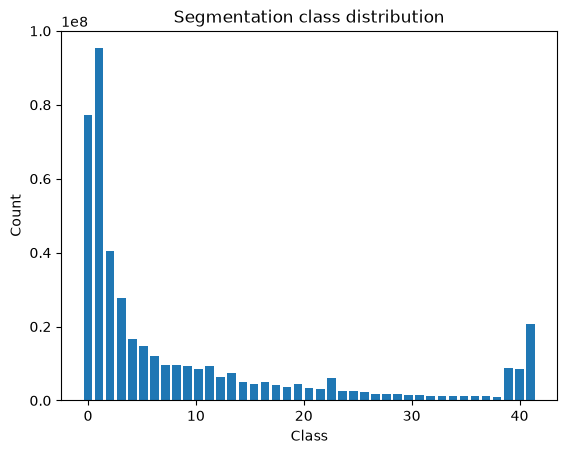

In [48]:
import matplotlib.pyplot as plt

classes = np.linspace(0, 41, num=41)
class_count_percent = (seg_class_count / sum(seg_class_count)) * 100
plt.bar(classes, seg_class_count)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Segmentation class distribution")
plt.show()

In [ ]:
print(class_count_percent)

tensor([17.3811, 21.3955,  9.0635,  6.2009,  3.7681,  3.3295,  2.6782,  2.1378,
         2.1623,  2.1201,  1.9332,  2.0844,  1.4385,  1.6721,  1.1108,  1.0195,
         1.1034,  0.9162,  0.8270,  0.9961,  0.7352,  0.7007,  1.3741,  0.5908,
         0.5826,  0.4941,  0.3902,  0.3662,  0.3768,  0.3375,  0.3179,  0.2946,
         0.2790,  0.2654,  0.2669,  0.2770,  0.2544,  0.2303,  1.9691,  1.9088,
         4.6503])
